In [1]:
%load_ext autoreload 
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import nibabel as nib
import os 
opj = os.path.join
%matplotlib inline 
sub = 'sub-03strip'
import subprocess
import shutil
# Get everything ready
BIDS_dir = '/Users/marcusdaghlian/projects/pilot-clean-link/'
output_path = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single'
if not os.path.exists(output_path):
    os.makedirs(output_path)
fs_dir = opj(BIDS_dir, 'derivatives', 'freesurfer')



Note on run-1; has 1 extra TR, so I have copied it, and chopped off the last tr
```bash
cp rsub-03_task-task-colbw_run-01_bold.nii rsub-03_task-task-colbw_run-01_boldFULL.nii
fslroi rsub-03_task-task-colbw_run-01_bold.nii rsub-03_task-task-colbw_run-01_bold.nii 0 90
rm rsub-03_task-task-colbw_run-01_bold.nii
gunzip rsub-03_task-task-colbw_run-01_bold.nii.gz
```

In [2]:
from dpu_mini.utils import *
def load_benson14_info(sub, fs_dir):
    ''' *no*
    '''
    sub_fs_dir = opj(fs_dir, sub, 'surf')    
    b14_dict = {}
    for p in ['eccen', 'angle', 'sigma', 'varea']:
        hemi_p = []
        for hemi in ['lh', 'rh']:
            b14_p_file = dag_find_file_in_folder(
                [hemi, p, 'benson14', '.mgz'],
                sub_fs_dir,
            )
            hemi_p.append(nib.load(b14_p_file).get_fdata().squeeze())   
        if p=='eccen':
            better_name = 'ecc'
        elif p=='angle':
            better_name = 'pol'
        elif p=='sigma':
            better_name = 'size_1'
        elif p=='varea':
            better_name = 'varea'
        b14_dict[better_name] = np.concatenate(hemi_p, axis=0)
    return b14_dict
b14_info = load_benson14_info(sub, fs_dir)

Could not find FS_LICENSE
Uncomment line below and specify path to FS_LICENSE


In [ ]:
import os
opj = os.path.join
moco_folder = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if (f.endswith('bold.nii') and f.startswith('rsub')) ]
rfiles = [f for f in rfiles if 'accordion' not in f]
rfiles.sort()
print(rfiles)
print(len(rfiles))

['/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-01_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-02_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-03_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-04_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-05_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-06_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-07_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-08_bold.nii', '/Users/marcusdaghlian/projects/pilot-c

In [477]:
# # os.system(f'cp {rfiles[0]} {rfiles[0].replace(".nii", "BU.nii")}')

# img = nib.load(rfiles[0])
# data = img.get_fdata()

# # Remove last volume along the 4th dimension
# data_trimmed = data[..., :-1]
# print(data_trimmed.shape)
# new_img = nib.Nifti1Image(data_trimmed, img.affine, img.header)
# nib.save(new_img, rfiles[0])

In [22]:


stest_dir = opj(output_path, f'{sub}_nonordic')
if os.path.exists(stest_dir):
    shutil.rmtree(stest_dir, )
os.makedirs(stest_dir)

fs_anat = opj(fs_dir, sub, 'mri', 'brain.mgz')
anat_ref = opj(stest_dir, 'anat_ref.nii.gz')
# Add the brain as anatomical ref

subprocess.run(
    ['mri_convert', fs_anat, anat_ref]
)




mri_convert /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/anat_ref.nii.gz 
reading from /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz...
TR=5000.00, TE=0.00, TI=0.00, flip angle=0.00
i_ras = (-1, 0, 0)
j_ras = (0, 0, -1)
k_ras = (0, 1, 0)
writing to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/anat_ref.nii.gz...


CompletedProcess(args=['mri_convert', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/anat_ref.nii.gz'], returncode=0)

In [23]:
# Add the ROIs
b14_vol = opj(stest_dir, 'b14_vol.nii.gz')
ndil = 2
b14_vol_dil = opj(stest_dir, f'b14_vol{ndil}.nii.gz')
cmd = ' '.join([
    f"mri_label2vol --temp {opj(fs_dir, sub, 'mri', 'orig.mgz')} ",
    f"--label lh.b14_V1.label --label rh.b14_V1.label "
    f"--label lh.b14_V2.label --label rh.b14_V2.label ",
    f"--label lh.b14_V3.label --label rh.b14_V3.label ",
    f"--o {b14_vol} --identity" ])
subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))
# Dilate to cover a bit more
cmd = ' '.join([
    'fslmaths', b14_vol, '-dilM ' * ndil, '-bin', b14_vol_dil
])
subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))

# Add the ROIs
b14_v2 = opj(stest_dir, 'b14_v2.nii.gz')
ndil = 2
b14_v2_dil = opj(stest_dir, f'b14_v2{ndil}.nii.gz')
cmd = ' '.join([
    f"mri_label2vol --temp {opj(fs_dir, sub, 'mri', 'orig.mgz')} ",
    f"--label lh.b14_V2.label --label rh.b14_V2.label ",
    f"--o {b14_v2} --identity" ])
subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))
# Dilate to cover a bit more
cmd = ' '.join([
    'fslmaths', b14_v2, '-dilM ' * ndil, '-bin', b14_v2_dil
])

subprocess.run(cmd, shell=True, check=True, )

subprocess.run(cmd, shell=True, check=True, )


Number of labels: 6
lh.b14_V1.label
rh.b14_V1.label
lh.b14_V2.label
rh.b14_V2.label
lh.b14_V3.label
rh.b14_V3.label
Annot File:      (null)
Template Volume: /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/orig.mgz
Outut Volume: /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/b14_vol.nii.gz
Registration File: (null)
Fill Threshold: 0
Label Vox Vol:  1
ProjType:       (null)
ProjTypeId:     0
ProjStart:      0
ProjStop:       0
ProjDelta:      0.1
Subject:  (null)
Hemi:     (null)
UseNewASeg2Vol:  0
DoLabelStatVol  0
LabelCodeOffset  0
setenv SUBJECTS_DIR /Users/marcusdaghlian/projects/dp-clean-link/pilot-clean/derivatives/freesurfer
dev
Template RAS-to-Vox: --------
-1.54545  -0.00000  -0.00000   170.00000;
-0.00000  -0.00000  -1.54545   170.00000;
-0.00000   1.54545  -0.00000   170.00000;
-0.00000  -0.00000  -0.00000   1.00000;
Template Voxel Volume: 0.270914
nHits Thresh: 0
Using Identity Mat

CompletedProcess(args='fslmaths /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/b14_v2.nii.gz -dilM -dilM  -bin /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/b14_v22.nii.gz', returncode=0)

In [24]:
grand_mean = opj(stest_dir, 'runmean.nii.gz')
grand_tsnr = opj(stest_dir, 'runtsnr.nii.gz')
env = os.environ.copy()
env["SUBJECTS_DIR"] = fs_dir

In [25]:
for tfile in [grand_mean, grand_tsnr]:
    if os.path.exists(tfile):
        os.remove(tfile)

n = len(rfiles)
if n == 0:
    raise ValueError("rfiles is empty")

for i, r in enumerate(rfiles):
    tmp_m    = opj(stest_dir, f'tmp_mean{i}.nii.gz')
    tmp_std  = opj(stest_dir, f'tmp_std{i}.nii.gz')
    tmp_tsnr = opj(stest_dir, f'tmp_tsnr{i}.nii.gz')

    # Temporal mean
    subprocess.run(['fslmaths', r, '-Tmean', tmp_m], check=True)

    # Temporal std
    subprocess.run(['fslmaths', r, '-Tstd', tmp_std], check=True)

    # tSNR = mean / std (per run)
    subprocess.run(['fslmaths', tmp_m, '-div', tmp_std, tmp_tsnr], check=True)

    if i == 0:
        subprocess.run(['cp', tmp_m,    grand_mean], check=True)
        subprocess.run(['cp', tmp_tsnr, grand_tsnr], check=True)
    else:
        subprocess.run(['fslmaths', grand_mean, '-add', tmp_m,    grand_mean], check=True)
        subprocess.run(['fslmaths', grand_tsnr, '-add', tmp_tsnr, grand_tsnr], check=True)
    tmp_files= os.listdir(stest_dir)
    tmp_files=[tfile for tfile in tmp_files if tfile.startswith('tmp')]
    for tfile in tmp_files:
        subprocess.run(['rm', opj(stest_dir, tfile)])
# Divide by number of files
subprocess.run(['fslmaths', grand_mean, '-div', str(n), grand_mean], check=True)
subprocess.run(['fslmaths', grand_tsnr, '-div', str(n), grand_tsnr], check=True)


CompletedProcess(args=['fslmaths', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runtsnr.nii.gz', '-div', '10', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runtsnr.nii.gz'], returncode=0)

In [26]:

# Reorient all outputs
for out in [grand_mean, grand_tsnr]:
    subprocess.run(['fslreorient2std', out, out], check=True)
    subprocess.run(['fslmaths', out, '-nan', out], check=True)

In [482]:
# # Now get the registration... 
# reg_dat = opj(stest_dir, 'bbreg.dat')
# fsl_mat = opj(stest_dir, 'bbreg.mat')
# reg_lta = opj(stest_dir, 'bbreg.lta')
# env = os.environ.copy()
# env["SUBJECTS_DIR"] = fs_dir
# cmd = ' '.join(
# [
#         'bbregister',
#         '--s', sub,
#         '--mov', grand_mean,
#         '--reg', reg_dat,
#         '--fslmat', fsl_mat,
#         '--bold', '--init-fsl'
#     ]
# )
# subprocess.run(
#     cmd,
#     env=env,
#     shell=True,
#     check=True
# )

In [27]:
# Version 2: more DOF
# Now get the registration... 
reg_dat = opj(stest_dir, 'bbreg.dat')
fsl_mat = opj(stest_dir, 'bbreg.mat')
reg_lta = opj(stest_dir, 'bbreg.lta')


In [28]:

env = os.environ.copy()
env["SUBJECTS_DIR"] = fs_dir
cmd = ' '.join(
[
        'flirt',
        '-in', grand_mean,
        '-ref', anat_ref,
        '-out', opj(stest_dir, 'rmFlirtInit.nii.gz'),
        '-omat', opj(stest_dir, 'rmFlirtInit.mat'),
        '-dof 12 ', 
        '-cost mutualinfo'
    ]
)
subprocess.run(cmd,env=env,shell=True,check=True)
print(cmd)
cmd = ' '.join([
    'tkregister2', '--s', sub, 
    '--mov', grand_mean, '--targ', anat_ref, 
    '--fsl', opj(stest_dir, 'rmFlirtInit.mat'), 
    '--reg', opj(stest_dir, 'rmFlirtInit.dat'), '--noedit', 
]
)
print(cmd)
subprocess.run(cmd, env=env, shell=True, check=True)

cmd = ' '.join([
    'bbregister',  '--s', sub, '--mov', grand_mean, 
    '--reg', reg_dat, '--fslmat', fsl_mat, 
    '--bold', '--init-reg',opj(stest_dir, 'rmFlirtInit.dat')
])
subprocess.run(cmd, env=env, shell=True, check=True)


flirt -in /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runmean.nii.gz -ref /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/anat_ref.nii.gz -out /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/rmFlirtInit.nii.gz -omat /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/rmFlirtInit.mat -dof 12  -cost mutualinfo
tkregister2 --s sub-03strip --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runmean.nii.gz --targ /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/anat_ref.nii.gz --fsl /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/rmFlirtInit.mat --reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


tmp /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/tmp.bbregister.85635
Log file is /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.log
Tue Mar 17 10:07:04 GMT 2026

setenv SUBJECTS_DIR /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer
cd /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/code/stripes_pipline/experimental/func
/Applications/freesurfer/8.1.0/bin/bbregister --s sub-03strip --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runmean.nii.gz --reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat --fslmat /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.mat --bold --init-reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_s

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


CompletedProcess(args='bbregister --s sub-03strip --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runmean.nii.gz --reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat --fslmat /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.mat --bold --init-reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/rmFlirtInit.dat', returncode=0)

In [29]:
# convert to lta
def func2anat(func, interp='trilin'):
    subprocess.run(
        ['fslreorient2std', func, func]
    )
    reg_lta = opj(stest_dir, 'tmp.lta')
    out = func.replace('.nii.gz', 'al.nii.gz')
    cmd = ' '.join(
        [
            'tkregister2',
            '--mov', func,
            '--reg', reg_dat,
            '--targ', opj(fs_dir, sub, 'mri', 'brain.mgz'),
            '--ltaout', reg_lta,
        ]
    )
    subprocess.run(
        cmd,env=env,shell=True,check=True
    )
    cmd = ' '.join(
        [
            'mri_vol2vol',
            '--mov', func,
            '--targ', opj(fs_dir, sub, 'mri', 'brain.mgz'),
            '--lta', reg_lta,
            '--interp', interp,
            '--o', out,
        ]
    )
    subprocess.run(
        cmd,env=env,shell=True,check=True
    )


In [30]:

func2anat(grand_mean)
func2anat(grand_tsnr)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runmean.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.00000;
 0.0

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/runtsnr.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done


In [31]:
import pandas as pd
rp = opj(moco_folder, [i for i in rfiles_ if 'rp' in i][0])
motion_all_FULL = np.loadtxt(rp) # includes the extra tr at 91
motion_all = np.vstack([motion_all_FULL[:91,:] , motion_all_FULL[92:,:]])


In [56]:
dm_file = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles/TestSubj_TestSess_Run1_colour_Cond.mat'
tdm_mat = sio.loadmat(dm_file)
tn_trs = 90 # 90 timepts
t_tr = 3 #
log_dir = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles'
dm_files_ = os.listdir(log_dir)
dm_files = [i for i in dm_files_ if '.mat' in i]
dm_files

dm_conds = [str(i[0]) for i in tdm_mat['names'][0]]
ons = {}
dur = {}
cond_list = []
for iC,c in enumerate(dm_conds):
    ons[c] = tdm_mat['onsets'][0][iC][0] # weird matlab... have to index this way
    print(ons[c])
    ons[c] = [int(i / t_tr) for i in ons[c]]
    print(ons[c])
    dur[c] = tdm_mat['durations'][0][iC][0] #int(tdm_mat['durations'][0][iC][0] // t_tr) # in trs
    if c != 'rest':
        cond_list.append(c)
dmatrix = np.zeros((tn_trs, len(cond_list)))
for iC,c in enumerate(cond_list):
    for tonset in ons[c]:
        # toffset = tonset+dur[c]
        # dmatrix[tonset:toffset,iC] = 1.0
        dmatrix[tonset,iC] = 1.0
dur = 30 # 

t_dmatrix_info = {
    'dur' : dur, 
    'cond_list' : cond_list, 
    'ons' : ons,
    'dmatrix' : dmatrix, 
}

[8.45125000e-04 2.55008815e+02]
[0, 85]
[ 45.00162958  75.01012975 165.00254796 195.00816542]
[15, 25, 55, 65]
[ 15.01033804 105.00170842 135.01069308 225.01644929]
[5, 35, 45, 75]


In [ ]:
import glmsingle
from glmsingle.glmsingle import GLM_single
import scipy
import os
import shutil
opj = os.path.join

output_full = opj(stest_dir,'glm_full_denoise_only')
opt = dict()
# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 0
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 0

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameter

In [34]:
rnib = [nib.load(f) for f in rfiles]
rdata = []
for i in range(len(rnib)):
    rdata.append(rnib[i].get_fdata())

In [54]:
rfiles

['/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-01_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-02_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-03_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-04_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-05_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-06_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-07_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-08_bold.nii',
 '/Users/marcusdaghlian/projects

In [35]:
# variables that will contain bold time-series and design matrices from each run
data = []
design = []

nruns = 0
for R in range(len(rdata)):
    data.append(
        np.nan_to_num(rdata[R]),
        )
    design.append(t_dmatrix_info['dmatrix'])
    nruns += 1

# get shape of data volume (XYZ) for convenience
xyz = data[0].shape[:3]
xyzt = data[0].shape

# get total number of blocks - this will be the dimensionality of output betas from GLMsingle
nblocks = int(np.sum(np.concatenate(design)))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0
# run GLMsingle
results_full = glmsingle_obj.fit(
   design,
   data,
   stimdur,
   tr,
   outputdir=output_full)

*** DIAGNOSTICS ***:
There are 10 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8].
The number of trials for each condition is: [np.int64(40), np.int64(40)].
For each condition, the number of runs in which it appears: [np.int64(10), np.int64(10)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/der

chunks: 100%|██████████| 24/24 [00:49<00:00,  2.06s/it]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 24/24 [04:45<00:00, 11.90s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 24/24 [00:35<00:00,  1.48s/it]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** All model types done ***

*** return model types in results ***



In [111]:
# brainmask = meanvol > 2500
tnruns = len(data)
beta_id = {'bw': [0, 3, 4, 7], 'col': [1, 2, 5, 6]} # within a run 
tbsplit = np.array_split(results_full['typec']['betasmd'], 10, axis=-1)
betas_full = {}
for k in beta_id.keys():
    betas_full[k] = []
    for iR in range(tnruns):
        for ibeta in beta_id[k]:
            betas_full[k].append(tbsplit[iR][:,:,:,ibeta])
    betas_full[k] = np.nanmean(betas_full[k], axis=0)

tdata_full = betas_full['col'] -  betas_full['bw']
tmask_full = results_full['typec']['meanvol']>5000
tdata_full[~tmask_full] = np.nan
timg = nib.Nifti1Image(tdata_full.astype(np.float32), rnib[0].affine)

tfile_full = opj(output_full, 'colmbw_mv5000.nii.gz')
tfile_full_al = opj(output_full, 'colmbw_mv5000al.nii.gz')
nib.save(timg, tfile_full)
func2anat(tfile_full)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/colmbw_mv5000.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/colmbw_mv5000.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/colmbw_mv5000al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774333371
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.00881 

error: File exists
error: WARNING: 944989 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_full_denoise_only/colmbw_mv5000.nii.gz...
 



Resampling
Output registration matrix is identity

mri_vol2vol done


## half half

In [43]:
run_indices = np.arange(len(rfiles))
splits = {
    1: run_indices[::2],   # interleaved: even runs
    2: run_indices[1::2],  # interleaved: odd runs
}
# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0
results = {}
for split in [1,2]:
   glm_out = opj(stest_dir, f'glm_split{split}_denoise_only')
   # variables that will contain bold time-series and design matrices from each run
   tdata = []
   tdesign = []

   nruns = 0
   for R in splits[split]:
      tdata.append(
         # np.nan_to_num(rdata[R]),
         rdata[R],
         )
      tdesign.append(t_dmatrix_info['dmatrix'])
      nruns += 1

   # get total number of blocks - this will be the dimensionality of output betas from GLMsingle
   nblocks = int(np.sum(np.concatenate(design)))

   tglm = GLM_single(opt)
   results[split] = tglm.fit(
      tdesign,
      tdata,
      stimdur,
      tr,
      outputdir=glm_out)

*** DIAGNOSTICS ***:
There are 5 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8, 8, 8, 8, 8].
The number of trials for each condition is: [np.int64(20), np.int64(20)].
For each condition, the number of runs in which it appears: [np.int64(5), np.int64(5)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0), np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/RUNWISEFIR.npy. ***

*** FITTI

/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 0.3552272482707049 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 24/24 [00:10<00:00,  2.33it/s]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



...


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split2_denoise_only/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 24/24 [04:33<00:00, 11.41s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 24/24 [00:45<00:00,  1.88s/it]



*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split2_denoise_only/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** All model types done ***

*** return model types in results ***



In [112]:
# brainmask = meanvol > 2500
betas = {}
beta_id = {'bw': [0, 3, 4, 7], 'col': [1, 2, 5, 6]} # within a run 
for split in [1,2]:
    tbsplit = np.array_split(results[split]['typec']['betasmd'], 5, axis=-1) # 5 because half
    betas[split] = {}
    for k in beta_id.keys():
        betas[split][k] = []
        for iR in range(5):
            for ibeta in beta_id[k]:
                betas[split][k].append(tbsplit[iR][:,:,:,ibeta])
        betas[split][k] = np.nanmean(betas[split][k], axis=0)




In [113]:
# betas = {}
# for split in [1, 2]:
#     betas[split] = {}
#     r2 = results[split]['typec']['R2run']  # (164, 164, 50, 5)

#     # R2-weighted mean: w_i = max(R2_i, 0) to exclude negative fits
#     r2_bw  = np.maximum(r2[:, :, :, ::2],  0)   # even runs
#     r2_col = np.maximum(r2[:, :, :, 1::2], 0)   # odd runs

#     w_sum_bw  = r2_bw.sum(axis=-1,  keepdims=True)
#     w_sum_col = r2_col.sum(axis=-1, keepdims=True)

#     # Fall back to uniform weights where all R2 <= 0
#     w_bw  = np.where(w_sum_bw  > 0, r2_bw  / w_sum_bw,  1 / r2_bw.shape[-1])
#     w_col = np.where(w_sum_col > 0, r2_col / w_sum_col, 1 / r2_col.shape[-1])

#     betas[split]['bw']  = np.nansum(results[split]['typec']['betasmd'][:, :, :, ::2]  * w_bw,  axis=-1)
#     betas[split]['col'] = np.nansum(results[split]['typec']['betasmd'][:, :, :, 1::2] * w_col, axis=-1)

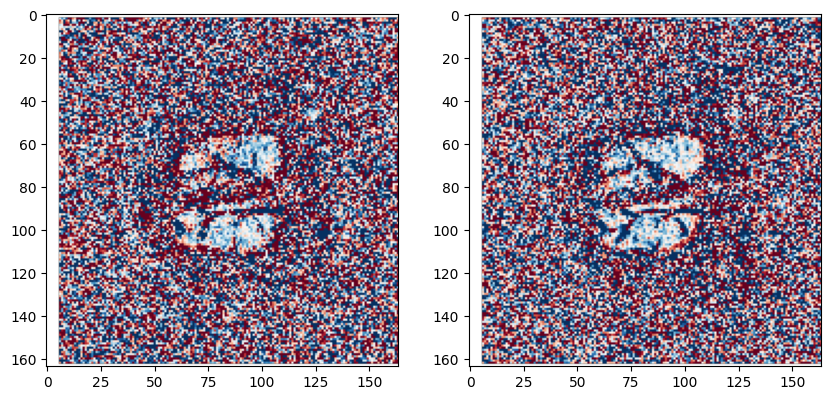

In [114]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
for iS,split in enumerate([1,2]):
    axs[iS].imshow(
        np.nanmean(
            results[split]['typec']['betasmd'][:,:,-10,:], axis=-1),
            vmin=-5, vmax=5, cmap='RdBu',
           )

16.509659
13.616989


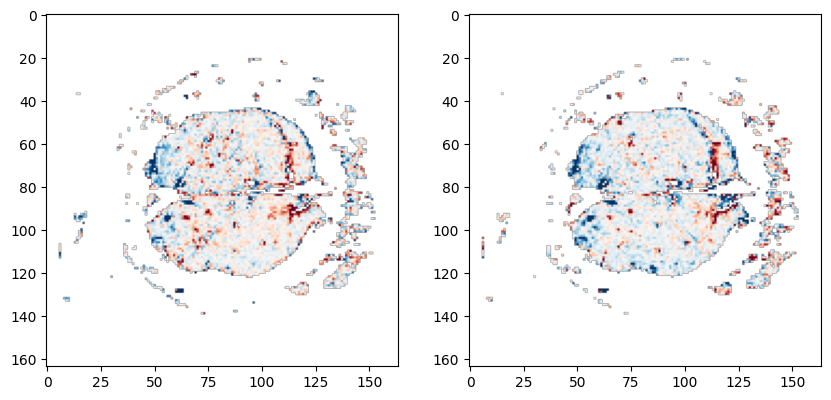

In [115]:
isl = -15
fig, axs = plt.subplots(1,2,figsize=(10,5))
for iS,split in enumerate([1,2]):
    tdata = betas[split]['bw'][:,:,isl] #np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10, :], axis=-1)
    tdata =  betas[split]['col'][:,:,isl] -  betas[split]['bw'][:,:,isl] 
    tmask = results[split]['typec']['meanvol'][:,:,isl]>4000
    tdata[~tmask] = np.nan
    print(np.nanmax(tdata))
    #results_glmsingle['typec']['meanvol'][:,:,-10]>3200,
    axs[iS].imshow(
        tdata,
        vmin=-3, vmax=3, cmap='RdBu',
        )
    # plt.colorbar()

In [116]:
tfile_als = {}
for split in [1,2]:
    tdata = betas[split]['col'] -  betas[split]['bw']
    tmask = results[split]['typec']['meanvol']>5000
    tdata[~tmask] = np.nan
    timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
    
    tfile = opj(stest_dir, f'glm_split{split}_denoise_only', 'colmbw_mv5000.nii.gz')
    tfile_al = opj(stest_dir, f'glm_split{split}_denoise_only', 'colmbw_mv5000al.nii.gz')
    tfile_als[split] = tfile_al
    nib.save(timg, tfile)
    func2anat(tfile)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;


INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.00000;
 0.00000   0.00000   1.00000  -128.00000;
 0.00000  -1.00000   0.00000   128.00000;
 0.00000   0.00000   0.00000   1.00000;
INFO: loading movable /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/colmbw_mv5000.nii.gz
Tmov: --------------------
-0.90244   0.00000   0.00000   74.00000;
 0.00000   0.00000   0.90244  -74.00000;
 0.00000  -0.90000   0.00000   22.50000;
 0.00000   0.00000   0.00000   1.00000;
mkheaderreg = 0, float2int = 0
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 

INFO: using NIfTI-1 sform (sform_code=2)



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/colmbw_mv5000.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/colmbw_mv5000.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split1_denoise_only/colmbw_mv5000al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774694344
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.

...


Matrix from LTA:
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53425;
 0.00409  -0.95898   0.31225  -74.93081;
 0.00000   0.00000   0.00000   1.00000;


INFO: using NIfTI-1 sform (sform_code=2)



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split2_denoise_only/colmbw_mv5000.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split2_denoise_only/colmbw_mv5000.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split2_denoise_only/colmbw_mv5000al.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilin (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1774733371
NaN found at voxel (0, 0, 0, 0)

Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.

error: File exists
error: WARNING: 945093 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_split2_denoise_only/colmbw_mv5000.nii.gz...
 



Resampling
Output registration matrix is identity

mri_vol2vol done


# 1 runs; 2 runs 

In [219]:
run_indices = np.arange(len(rfiles))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0
resultsNr = {}
for r in run_indices:
   glm_out = opj(stest_dir, f'glm_splitR{r}_denoise_only')
   # variables that will contain bold time-series and design matrices from each run
   tdata = []
   tdesign = []

   nruns = 0
   tdata = [rdata[r]]
   tdesign = t_dmatrix_info['dmatrix']

   # get total number of blocks - this will be the dimensionality of output betas from GLMsingle
   nblocks = int(np.sum(np.concatenate(design)))

   tglm = GLM_single(opt)
   resultsNr[r] = tglm.fit(
      tdesign,
      tdata,
      stimdur,
      tr,
      outputdir=glm_out)

*** DIAGNOSTICS ***:
There are 1 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8].
The number of trials for each condition is: [np.int64(4), np.int64(4)].
For each condition, the number of runs in which it appears: [np.int64(1), np.int64(1)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR0_denoise_only/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***


/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/glmsingle/glmsingle.py:657: UserWarning: None of your conditions occur in more than one run. Are you sure this is what you intend?
  warnings.warn(msg)
/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/glmsingle/glmsingle.py:667: UserWarning: Since there are no repeats, standard cross-validation usage of <wantglmdenoise> cannot be performed. Setting <wantglmdenoise> to 0.
  warnings.warn(msg)


*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR0_denoise_only/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR0_denoise_only/TYPEA_ONOFF.npy. ***



/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 1.3608297839492 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



...

*** Saving FIR results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR9_denoise_only/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR9_denoise_only/TYPEA_ONOFF.npy. ***



/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 1.0265421200046032 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 24/24 [00:02<00:00, 11.96it/s]


*** Saving results to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR9_denoise_only/TYPEB_FITHRF.npy. ***

*** All model types done ***

*** return model types in results ***



In [222]:
# brainmask = meanvol > 2500
betasNr = {}
beta_id = {'bw': [0, 3, 4, 7], 'col': [1, 2, 5, 6]} # within a run 
for r in run_indices:
    betasNr[r] = {}
    for k in beta_id.keys():
        betasNr[r][k] = []
        for ibeta in beta_id[k]:
            betasNr[r][k].append(resultsNr[r]['typeb']['betasmd'][:,:,:,ibeta])
        betasNr[r][k] = np.nanmean(betasNr[r][k], axis=0)




In [232]:
# R2 MEAN
beta_id = {'bw': [0, 3, 4, 7], 'col': [1, 2, 5, 6]}

# Per-run condition averages and R2 maps
betasNr = {}
r2Nr = {}
for r in run_indices:
    r2Nr[r] = resultsNr[r]['typeb']['R2']  # shape (X, Y, Z)
    betasNr[r] = {}
    for k, indices in beta_id.items():
        betas = np.stack(
            [resultsNr[r]['typeb']['betasmd'][..., i] for i in indices],
            axis=0
        )
        betasNr[r][k] = np.nanmean(betas, axis=0)  # shape (X, Y, Z)

# R2-weighted mean across runs
r2_stack = np.stack([r2Nr[r] for r in run_indices], axis=0)  # (n_runs, X, Y, Z)
r2_sum = np.nansum(r2_stack, axis=0)  # (X, Y, Z), avoid div-by-zero below

betasNr_full = {}
for k in beta_id:
    betas_stack = np.stack([betasNr[r][k] for r in run_indices], axis=0)  # (n_runs, X, Y, Z)
    betasNr_full[k] = np.nansum(betas_stack * r2_stack, axis=0) / np.where(r2_sum > 0, r2_sum, np.nan)

In [236]:
tfile_al_nRs = {}
for r in run_indices:
    tdata = betasNr[r]['col'] -  betasNr[r]['bw']
    tmask = resultsNr[r]['typeb']['meanvol']>5000
    tdata[~tmask] = np.nan
    timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
    
    tfile = opj(stest_dir, f'glm_splitR{r}_denoise_only', 'colmbw_mv5000.nii.gz')
    tfile_al = opj(stest_dir, f'glm_splitR{r}_denoise_only', 'colmbw_mv5000al.nii.gz')
    tfile_al_nRs[r] = tfile_al
    nib.save(timg, tfile)
    func2anat(tfile)


# R2w mean
tdata = betasNr_full['col'] -  betasNr_full['bw']
tmask = resultsNr[r]['typeb']['meanvol']>5000
tdata[~tmask] = np.nan
timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)

tfile = opj(stest_dir, 'colmbw_mv5000R2W.nii.gz')
tfile_al = opj(stest_dir, 'colmbw_mv5000R2Wal.nii.gz')
tfile_al_nRs['r2wfull'] = tfile_al
nib.save(timg, tfile)
func2anat(tfile)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR0_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 939618 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR0_denoise_only/colmbw_mv5000.nii.gz...
 



Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53423;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
 0.72020  -0.00149  -0.00632  -40.68542;
 0.00294   0.22449   0.68947  -47.61701;
 0.00031  -0.69306   0.22544   159.74243;
 0.00000   0.00000   0.00000   1.00000;

Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR1_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043  

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 941795 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR1_denoise_only/colmbw_mv5000.nii.gz...
 



Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53423;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
 0.72020  -0.00149  -0.00632  -40.68542;
 0.00294   0.22449   0.68947  -47.61701;
 0.00031  -0.69306   0.22544   159.74243;
 0.00000   0.00000   0.00000   1.00000;

Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR2_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043  

...


Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR9_denoise_only/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53427;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affec

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 942363 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/glm_splitR9_denoise_only/colmbw_mv5000.nii.gz...
 



Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53423;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
 0.72020  -0.00149  -0.00632  -40.68542;
 0.00294   0.22449   0.68947  -47.61701;
 0.00031  -0.69306   0.22544   159.74243;
 0.00000   0.00000   0.00000   1.00000;

Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03strip/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/colmbw_mv5000R2W.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 942363 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03strip_nonordic/colmbw_mv5000R2W.nii.gz...
 



Final tkRAS-to-tkRAS Matrix is:
 1.00444   0.00881  -0.00208   1.42519;
-0.00043   0.31442   0.96659  -1.53423;
 0.00409  -0.95898   0.31225  -74.93083;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
 0.72020  -0.00149  -0.00632  -40.68542;
 0.00294   0.22449   0.68947  -47.61701;
 0.00031  -0.69306   0.22544   159.74243;
 0.00000   0.00000   0.00000   1.00000;

Resampling
Output registration matrix is identity

mri_vol2vol done


# combine for plotting

In [243]:
import cortex

# Force the reload

vols = {}
vols['col_m_bwfull'] = nib.load(tfile_full_al).get_fdata().transpose(2,1,0)
for split in [1,2]:
    vols[f'col_m_bw{split}'] = nib.load(tfile_als[split]).get_fdata().transpose(2,1,0)
for r in run_indices:
    vols[f'col_m_bwR{r}'] = nib.load(tfile_al_nRs[r]).get_fdata().transpose(2,1,0)
vols[f'col_m_bwR2W'] = nib.load(tfile_al_nRs['r2wfull']).get_fdata().transpose(2,1,0)
vols['tsnr'] = nib.load(opj(stest_dir, f'runtsnral.nii.gz')).get_fdata().transpose(2,1,0)
vols['mepi'] = nib.load(opj(stest_dir, f'runmeanal.nii.gz')).get_fdata().transpose(2,1,0)
maps = {}

for v in vols.keys():
    if v not in ('tsnr', 'mepi'):        
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            vmin=-2, vmax=2,
            cmap='RdBu_r'
        )
    else:
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            # vmin=-3, vmax=3,
            # cmap='RdBu_r'
        )



maps['b14ecc']= cortex.Vertex(
    b14_info['ecc'], sub, 
    cmap='jet', vmin=0, vmax=10, 
)
maps['b14pol']= cortex.Vertex(
    b14_info['pol'], sub, 
    cmap='hsv', vmin=0, vmax=180, 
)



In [240]:
cortex.webshow(maps)

Started server on port 48119


<JS: window.viewer>

Stopping server


In [244]:
cortex.webgl.make_static(
    './multi_glm',
    maps, )

# direct surface - testing

In [120]:
import cortex
import cortex.mapper
# get the mapper for your subject/transform
mapper = cortex.mapper.get_mapper(sub, xfmname='identity', type='trilinear')
surf_data = {}
for k in maps.keys():
    if k in ('b14ecc', 'b14pol'):
        surf_data[k] = maps[k].data
    else:
        surf_data[k] = mapper(maps[k]).data
tmask = (surf_data['b14ecc'] < 10) & \
    (surf_data['tsnr']>5)


In [121]:
from dpu_mini.mesh_maker import *
import dpu_mini.pyctx_cannibalized.subsurf2 as pcx
from dpu_mini.fs_tools import *
# gm = GenMeshMaker(sub, fs_dir=fs_dir)
gm = pcx.PyctxMaker(
    sub=sub, 
    fs_dir=fs_dir, 
)
gm.add_flat_to_mesh_info_ctx()
b14_all = dag_load_roi(
    sub, 
    'b14_V',
    # ['b14_V1', 'b14_V2'], 
    combine_matches=True, fs_dir=fs_dir)
b14_all &= b14_info['ecc']<20.0
# gm.rescale_mesh_info('flat')
gm.make_flat_map(b14_all, morph=20, hemi_project='flat', flat_name='flatcut', method='none')
gm.rescale_mesh_info('flatcut')

Using fs dir = /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer
/Users/marcusdaghlian/programs/pycortex/cortex/../filestore/db
default
default
Faces with missing vx: 226691
Faces with long edges: 845
0.16886410107954003
Faces with missing vx: 225199
Faces with long edges: 1070
0.18653068439679213


[np.float64(-216.8380723163812), np.float64(138.07910285315768)]
[np.float64(-153.43057370589278), np.float64(137.65882574619334)]
[np.float64(-216.8380723163812), np.float64(138.07910285315768)]
[np.float64(-153.43057370589278), np.float64(137.65882574619334)]


{'cmap': 'RdBu', 'vmin': -2, 'vmax': 2}

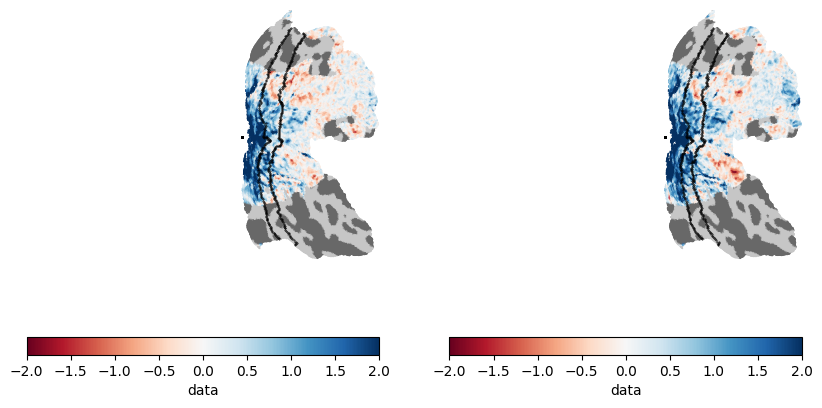

In [122]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
plt_kwargs = dict(
    cmap='RdBu', 
    vmin=-2, vmax=2, roi_list='b14_V2', 
    hemi_list=['rh'], 
    flat_name='flatcut', 

)
gm.flat_mpl(
    data=surf_data['col_m_bw1'],
    data_mask=tmask,
    ax=axs[0], **plt_kwargs
    )
# axs[0].set_xlim(-100, 0)
# axs[0].set_aspect('equal')
gm.flat_mpl(
    data=surf_data['col_m_bw2'],
    data_mask=tmask,
    ax=axs[1], **plt_kwargs
    )


In [197]:
mask = dag_load_roi(
    sub, 
    # 'rh.b14_V2',
    ['rh.b14_V1', 'rh.b14_V2',  'rh.b14_V3.'], 
    fs_dir=fs_dir, combine_matches=True)
# mask = dag_load_roi(sub, ['lh.b14_V2', ], fs_dir=fs_dir, combine_matches=True)
mask = dag_morph_roi(gm, mask, morph=2)
print(mask.sum())




12546


In [198]:
import scipy as sp
sm = gm.return_pyc_sm(mask=mask, hemi='rh', surf='pial')
B, D, W, V = sm.laplace_operator
npt = W.shape[0]
Dinv = sp.sparse.dia_matrix((D**-1, [0]), (npt, npt)).tocsr()
L = Dinv.dot((V - W))
nmodes = 200
eigenvalues, eigenvectors = sp.sparse.linalg.eigs(-L, k=nmodes, which="LM", sigma=0)
# Sort ascending by eigenvalue
idx = np.argsort(eigenvalues.real)
eigenvalues = eigenvalues.real[idx]      # (200,) — index 0 is DC (λ≈0)
eigenvalues[0] = 0
eigenvectors = eigenvectors.real[:, idx] # (npt, 200)
eigenvectors[:,-1] = 1
# Now get spatial frequency from gd + eigenvectors

sf = np.sqrt(np.abs(eigenvalues))/(np.pi*2)


In [549]:
gd = dag_pairwise_geodesic_distance(
    gm.mesh_info['pial']['rh'], mask[gm.n_vx['lh']:])

12546
Creating distance by distance matrices


Calculating geodesic distances:   0%|          | 0/12546 [00:00<?, ?it/s]/Users/marcusdaghlian/miniforge3/envs/pctx01/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
Calculating geodesic distances: 100%|██████████| 12546/12546 [00:32<00:00, 383.99it/s]


In [563]:
def autocorrelogram_frequency(phi, D, n_bins=100, n_freqs=500, max_dist=None):
    N = len(phi)
    if max_dist is None:
        max_dist = np.percentile(D[D > 0], 90)

    # Compute autocorrelogram
    i_idx, j_idx = np.triu_indices(N, k=1)
    dists = D[i_idx, j_idx]
    products = phi[i_idx] * phi[j_idx]

    bins = np.linspace(0, max_dist, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    R = np.array([products[np.digitize(dists, bins) - 1 == b].mean() 
                  for b in range(n_bins)])

    # Grid search: dot R against candidate cosines
    f_grid = np.linspace(0, 1/bin_centers[1], n_freqs)  # max freq ~ Nyquist of bin spacing
    cosines = np.cos(2 * np.pi * f_grid[:, None] * bin_centers[None, :])  # (n_freqs, n_bins)
    power = cosines @ R  # (n_freqs,)

    best_f = f_grid[np.argmax(power)]
    return best_f, bin_centers, R, f_grid, power

In [564]:
best_f, bin_centers, R, f_grid, power = autocorrelogram_frequency(
    eigenvectors, gd, 
)

: 

In [135]:
plt.scatter(
    gd[-1,:], 
    eigenvectors[:,0], 
)

NameError: name 'gd' is not defined

In [199]:

def get_z_fit(z, Phi, ):
    coeffs, _, _, _ = np.linalg.lstsq(Phi, z, rcond=None)
    z_fit = Phi @ coeffs
    ss_res = np.sum((z - z_fit) ** 2)
    ss_tot = np.sum((z - np.mean(z)) ** 2)
    print(f"R²: {1 - ss_res/ss_tot:.4f}")
    return z_fit, coeffs


zf, coef = get_z_fit(
    surf_data['col_m_bw1'][mask], eigenvectors
)
# coef[:20] = 0 
coef[190:] = 0 
zf2 = eigenvectors @ coef
coef

R²: 0.6039


array([ 2.48170264e+01,  1.79268866e+01,  1.79268866e+01, -7.54860198e-01,
       -1.83056237e+01, -1.83056237e+01, -2.48563439e+00, -2.48563439e+00,
        4.86817452e+00,  4.86817452e+00,  6.81779636e-01,  6.81779636e-01,
        3.54981145e+00,  1.59846590e+00, -5.72446920e+00, -5.72446920e+00,
        1.06294366e+00,  1.06294366e+00, -7.24545079e+00, -7.24545079e+00,
        6.86588067e+00,  7.73445100e+00, -5.90630835e-01,  1.41591341e+00,
        1.41591341e+00, -2.37836307e+00, -2.37836307e+00,  4.71950829e+00,
       -1.25952309e+00, -1.25952309e+00, -4.00285488e+00,  1.05927718e-01,
        4.94340190e+00,  4.94340190e+00, -2.79335153e+00,  2.00864205e+01,
       -7.35997539e+00, -7.35997539e+00, -5.07020661e+00, -5.07020661e+00,
        2.48668620e+00,  6.53417980e-01, -2.31102437e+00, -2.31102437e+00,
       -8.31131195e+00, -8.31131195e+00,  4.75271450e+00, -1.94435905e+00,
       -1.94435905e+00, -3.95866121e+00, -3.95866121e+00,  8.65201512e+00,
        8.65201512e+00, -

In [195]:
coef

array([ -2.63846943,  -1.7279751 ,  -1.7279751 ,  -1.20637388,
        -1.20637388,   1.34062269,  -2.38604709,  -2.38604709,
         1.77625872,   1.77625872,  -2.88460691,  -2.88460691,
         0.38999483,  -0.87518011,  -0.87518011,  -0.75538875,
         3.12936198,   3.12936198,  -0.13351935,  -0.13351935,
        -2.22831862,  -2.22831862,  -5.00739268,  -5.00739268,
        -1.72293091,  -1.72293091,  -5.13137648,  -5.13137648,
         1.79530988,   1.79530988,  -5.74374535,  -5.74374535,
         2.94436687,  -0.96338814,  -0.96338814,  -0.48573291,
        -0.48573291,   8.60590566,  -2.77883626,  -2.77883626,
         6.10671932,   6.10671932,   2.59461966,   7.2490718 ,
         7.2490718 ,  -2.45484883,   0.86968564,   0.86968564,
        -2.30740172,  -2.30740172,   4.70767178,   4.70767178,
        -4.18355812,  -4.18355812,  -0.44881251,  -0.44881251,
         2.33949487,   2.33949487,  -0.79556755,  -0.79556755,
         3.56662301,   3.56662301,  -4.61303275,  -4.61

(200,)

In [142]:
surf_data.keys()

dict_keys(['col_m_bwfull', 'col_m_bw1', 'col_m_bw2', 'tsnr', 'mepi', 'b14ecc', 'b14pol'])

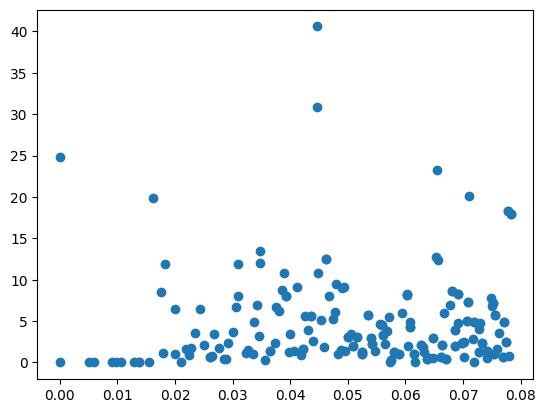

In [200]:
plt.scatter(
    sf, np.abs(coef)
)

[np.float64(-151.24525991743934), np.float64(216.37124758389632)]
[np.float64(-147.2140249397235), np.float64(172.5531299741894)]
[np.float64(-216.8380723163812), np.float64(216.37124758389632)]
[np.float64(-153.43057370589278), np.float64(172.5531299741894)]


{'cmap': 'RdBu_r',
 'vmin': np.float64(-1.5581896186721778),
 'vmax': np.float64(1.5188513580201881)}

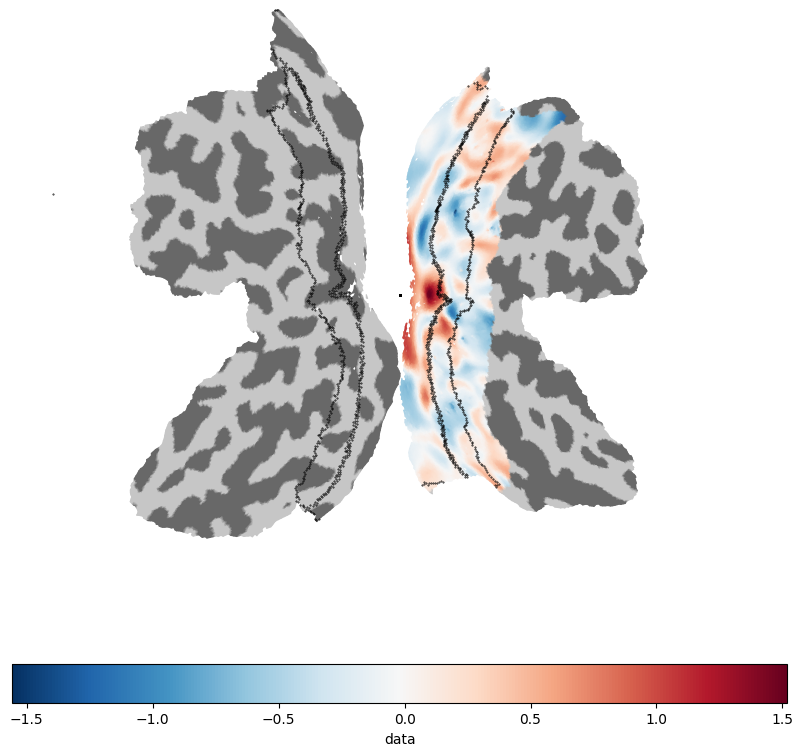

Stopping server


In [201]:
gm.flat_mpl(
    data=zf2, #surf_data['col_m_bw1'][mask], 
    data_sub_mask=mask, 
    flat_name='flatcut', 
    # vmin=-3, vmax=3, 
    # vmin=-.1, vmax=.1, 
    cmap='RdBu_r', 
    roi_list=['b14_V1', 'b14_V2']
)

[np.float64(-151.24525991743934), np.float64(216.37124758389632)]
[np.float64(-147.2140249397235), np.float64(172.5531299741894)]
[np.float64(-216.8380723163812), np.float64(216.37124758389632)]
[np.float64(-153.43057370589278), np.float64(172.5531299741894)]


{'cmap': 'viridis',
 'vmin': np.float64(0.0),
 'vmax': np.float64(110.99858093261719)}

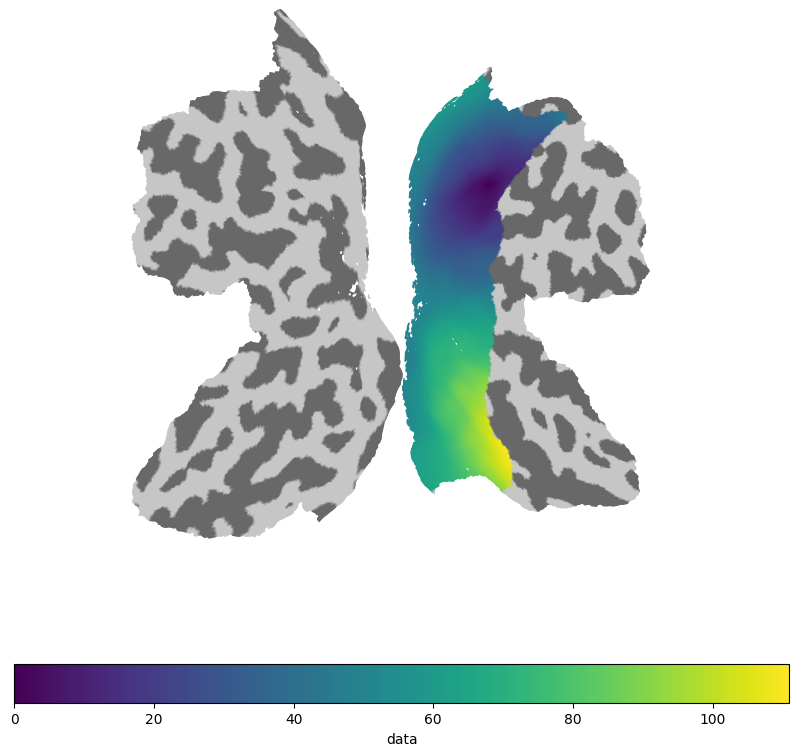

In [494]:
gm.flat_mpl(
    # data=eigenvectors.real[:,-20], #
    data=geo_dists[iS,:],
    data_sub_mask=mask, 
    flat_name='flatcut'
)

In [ ]:
# For each mode, bin the product φ(x)*φ(y) by geodesic distance
# max_dist = 30.0    # mm — beyond this correlation is noise
nbins = 500
bin_edges = np.linspace(0, 500, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

wavelengths = np.zeros(nmodes)

for k in range(nmodes):
    phi = eigenvectors[:, k]          # (npt,)
    phi_seeds = phi[seed_verts]       # (n_sample,)
    phi_all   = phi[np.newaxis, :]    # (1, npt)
    
    # product at each (seed, target) pair: (n_sample, npt)
    products = phi_seeds[:, np.newaxis] * phi_all
    
    # bin by geodesic distance
    corr = np.zeros(nbins)
    counts = np.zeros(nbins)
    bin_idx = np.digitize(geo_dists, bin_edges) - 1
    valid = (bin_idx >= 0) & (bin_idx < nbins)
    
    np.add.at(corr,   bin_idx[valid], products[valid])
    np.add.at(counts, bin_idx[valid], 1)
    corr /= np.maximum(counts, 1)
    
    # normalize so corr[0] ≈ 1
    corr /= np.abs(corr).max() + 1e-12
    
    # find first zero-crossing → half-wavelength
    sign_changes = np.where(np.diff(np.sign(corr)))[0]
    if len(sign_changes) > 0:
        wavelengths[k] = 2 * bin_centers[sign_changes[0]]  # full wavelength
    else:
        wavelengths[k] = np.nan

cycles_per_mm = 1.0 / wavelengths


In [459]:
cycles_per_mm

array([0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.09090

In [ ]:
# for i, sv in enumerate(seed_verts):
#     geo_dists[i] = trimesh.graph.vertex_geodesics(mesh, [sv])

# # For each mode, bin the product φ(x)*φ(y) by geodesic distance
# max_dist = 30.0    # mm — beyond this correlation is noise
# nbins = 100
# bin_edges = np.linspace(0, max_dist, nbins + 1)
# bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# # for i, sv in enumerate(seed_verts):
# #     geo_dists[i] = trimesh.graph.vertex_geodesics(mesh, [sv])
    
# #     # For each mode, bin the product φ(x)*φ(y) by geodesic distance
# #     max_dist = 30.0    # mm — beyond this correlation is noise
# #     nbins = 100
# #     bin_edges = np.linspace(0, max_dist, nbins + 1)
# #     bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
# #     wavelengths = np.zeros(n_modes)
    
# #     for k in range(n_modes):
# #         phi = eigenvectors[:, k]          # (npt,)
# #         phi_seeds = phi[seed_verts]       # (n_sample,)
# #         phi_all   = phi[np.newaxis, :]    # (1, npt)
        
# #         # product at each (seed, target) pair: (n_sample, npt)
# #         products = phi_seeds[:, np.newaxis] * phi_all
        
# #         # bin by geodesic distance
# #         corr = np.zeros(nbins)
# #         counts = np.zeros(nbins)
# #         bin_idx = np.digitize(geo_dists, bin_edges) - 1
# #         valid = (bin_idx >= 0) & (bin_idx < nbins)
        
# #         np.add.at(corr,   bin_idx[valid], products[valid])
# #         np.add.at(counts, bin_idx[valid], 1)
# #         corr /= np.maximum(counts, 1)
        
# #         # normalize so corr[0] ≈ 1
# #         corr /= np.abs(corr).max() + 1e-12
        
# #         # find first zero-crossing → half-wavelength
# #         sign_changes = np.where(np.diff(np.sign(corr)))[0]
# #         if len(sign_changes) > 0:
# #             wavelengths[k] = 2 * bin_centers[sign_changes[0]]  # full wavelength
# #         else:
# #             wavelengths[k] = np.nan
    
# #     cycles_per_mm = 1.0 / wavelengths
# #     return cycles_per_mm, wavelengths, bin_centers, corr  # last two for diagnostics



[np.float64(-151.24525991743934), np.float64(216.37124758389632)]
[np.float64(-147.2140249397235), np.float64(172.5531299741894)]
[np.float64(-216.8380723163812), np.float64(216.37124758389632)]
[np.float64(-153.43057370589278), np.float64(172.5531299741894)]


{'cmap': 'viridis',
 'vmin': np.float64(0.0),
 'vmax': np.float64(128.63186645507812)}

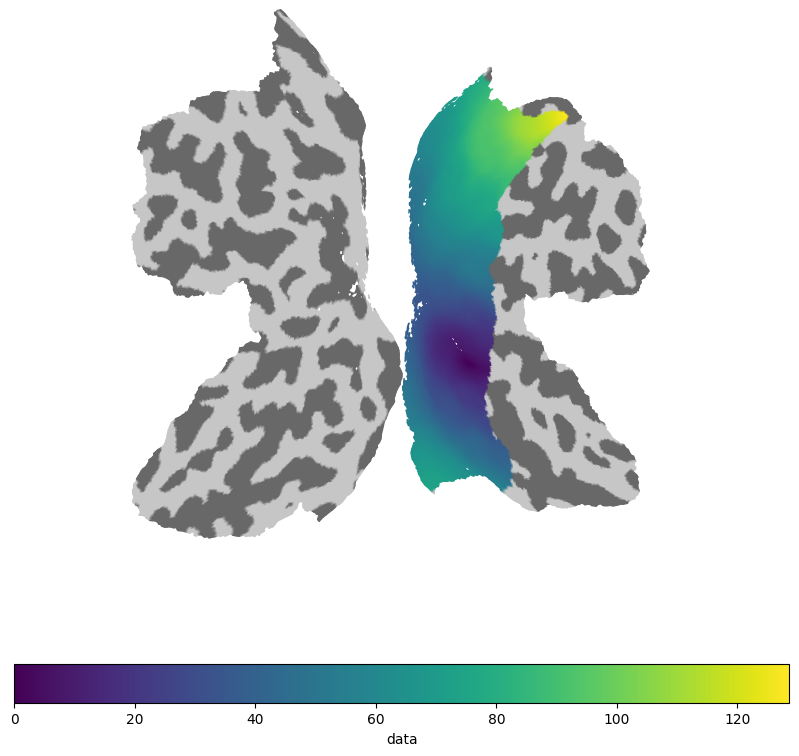

In [442]:
gm.flat_mpl(
    data=geo_dists[0,:], 
    data_sub_mask=mask, 
    flat_name='flatcut'
)

In [434]:
npt

12546

In [433]:
sm.geodesic_distance(i, m=100).shape

(12546,)

In [429]:
seed_verts

array([ 5130, 11162,  4508,  1432,  4971,  3493,  7269,  9080, 10460,
       11250,  7306,  9226,  6400,  4030,  2805,  5584,  9612,  3022,
       10007,  3474, 12224,  8007,   215, 10223,  9472,  7657,  5642,
        5216,  9712,  8916, 11268,  2191,  7199,  2004, 11673,    78,
        5064,  9048,  1696,  8742,  1279, 10163,  7664,  1791,  6712,
        7218,   300,  6036, 11185, 11615,  3465,  6303, 11562,  3796,
        8021,  6152,  5913,  1600,  3642, 11780,  4813,   979, 11231,
        6869,  1498,  5254,  1587, 10005,  8952,  1022,  8668,   304,
        9745, 10475,  2421,  5055,  7044,  9289,  8417, 11246,  6140,
        3596,  1477, 11757,  8220,   217,  1599,  3388,  2786,  2115,
         169, 11341,  1746,  5265,  6079,  6062, 11800, 12458,  9441,
       12122, 12320,  3407,  2386,   544, 10626,  8748,  7284,  4463,
        2179,  9077,  1863, 10843, 10105,   822,  1492,   388,  2930,
       11528, 11396,    64,  3193,  4623, 12331,  8964,  1149, 10787,
        4548,  4994,

In [ ]:

def get_z_fit(z):
    Phi = eigenvectors[:, 1:]                          # drop DC mode → (npt, 199)
    Phi = np.hstack([np.ones((npt, 1)), Phi])          # add explicit bias → (npt, 200)
    coeffs, _, _, _ = np.linalg.lstsq(Phi, z, rcond=None)
    z_fit = Phi @ coeffs
    ss_res = np.sum((z - z_fit) ** 2)
    ss_tot = np.sum((z - np.mean(z)) ** 2)
    print(f"R²: {1 - ss_res/ss_tot:.4f}")
    return z_fit, coeffs

z_fit = {}
z_fit[1], coeff1 = get_z_fit(z=surf_data['col_m_bw1'][mask])
z_fit[2], coeff2 = get_z_fit(z=surf_data['col_m_bw2'][mask])


In [427]:
geo_dists

[array([  0.        ,   0.99583048,   0.37461956, ...,  40.455348  ,
         46.63257972, 106.58624549], shape=(12546,)),
 array([  0.35868994,   0.        ,   0.7437692 , ...,  39.61110235,
         46.54960541, 105.8602903 ], shape=(12546,)),
 array([  0.66993166,   1.64039056,   0.        , ...,  40.84529132,
         46.19372978, 107.00543413], shape=(12546,))]

In [ ]:

def plot_power_spectrum(coeffs_list, labels, eigenvalues, colors=None):
    """eigenvalues: sorted real array including DC at index 0"""
    eigs_no_dc = eigenvalues[1:]                                        # (199,)
    spatial_freq = np.sqrt(np.abs(eigs_no_dc)) / (2 * np.pi)           # cycles/mm

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    nbins = 50
    bin_edges = np.linspace(spatial_freq.min(), spatial_freq.max(), nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for i, (coeffs, label) in enumerate(zip(coeffs_list, labels)):
        c = coeffs[1:]                  # drop bias → (199,), matches eigs_no_dc
        power = c ** 2

        col = colors[i] if colors else None
        axes[0].semilogy(eigs_no_dc, power, label=label, alpha=0.8, color=col)

        bin_power = np.array([
            power[(spatial_freq >= bin_edges[b]) & (spatial_freq < bin_edges[b+1])].sum()
            for b in range(nbins)
        ])
        axes[1].semilogy(bin_centers, bin_power + 1e-12, label=label, alpha=0.8, color=col)

    axes[0].set_xlabel('Eigenvalue λ (1/mm²)')
    axes[0].set_ylabel('Power (coeff²)')
    axes[0].set_title('Power vs eigenvalue')
    axes[0].legend()

    axes[1].set_xlabel('Spatial frequency (cycles/mm)')
    axes[1].set_ylabel('Power (summed in bin)')
    axes[1].set_title('Power spectrum (cycles/mm)')
    axes[1].legend()

    plt.tight_layout()
    return fig, axes

fig, axes = plot_power_spectrum(
    coeffs_list=[coeff1, coeff2],
    labels=['bw1', 'bw2'],
    eigenvalues=eigenvalues,
    colors=['steelblue', 'tomato']
)
plt.show()

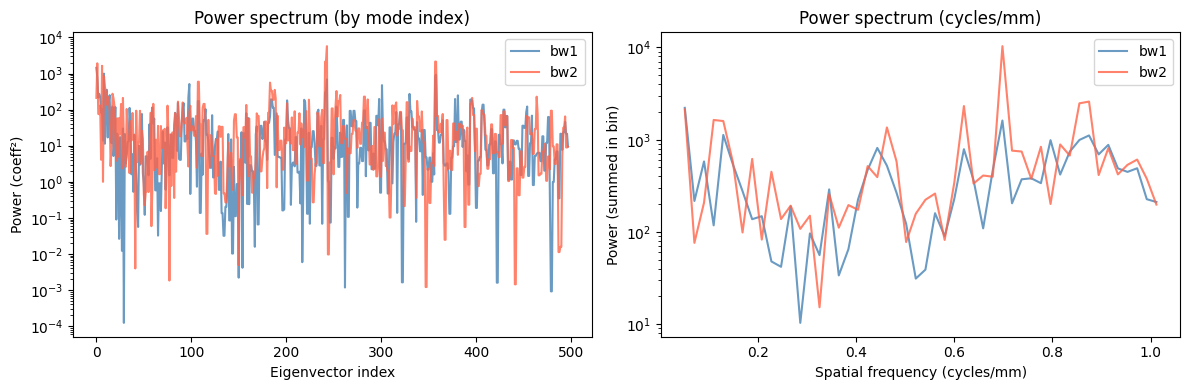

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_power_spectrum(coeffs_list, labels, eigenvalues, colors=None):
    """
    coeffs_list : list of coeff arrays (one per condition), first coeff is bias
    eigenvalues : real part, length k (excluding DC, matching Phi[:,1:])
    """
    freqs_eig = eigenvalues.real[1:]          # drop DC eigenvalue (≈0)
    spatial_freq = np.sqrt(np.abs(freqs_eig)) / (2 * np.pi)   # cycles/mm

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for i, (coeffs, label) in enumerate(zip(coeffs_list, labels)):
        c = coeffs[1:]                         # drop bias coeff
        power = c ** 2                         # raw power per mode

        col = colors[i] if colors else None

        # --- Left: power vs eigenvalue index ---
        axes[0].semilogy(power, label=label, alpha=0.8, color=col)

        # --- Right: power vs cycles/mm (binned for readability) ---
        # bin into ~50 frequency bands
        nbins = 50
        bin_edges = np.linspace(spatial_freq.min(), spatial_freq.max(), nbins+1)
        bin_power = np.zeros(nbins)
        for b in range(nbins):
            in_bin = (spatial_freq >= bin_edges[b]) & (spatial_freq < bin_edges[b+1])
            bin_power[b] = power[in_bin].sum()
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        axes[1].semilogy(bin_centers, bin_power, label=label, alpha=0.8, color=col)

    axes[0].set_xlabel('Eigenvector index')
    axes[0].set_ylabel('Power (coeff²)')
    axes[0].set_title('Power spectrum (by mode index)')
    axes[0].legend()

    axes[1].set_xlabel('Spatial frequency (cycles/mm)')
    axes[1].set_ylabel('Power (summed in bin)')
    axes[1].set_title('Power spectrum (cycles/mm)')
    axes[1].legend()

    plt.tight_layout()
    return fig, axes

fig, axes = plot_power_spectrum(
    coeffs_list=[coeff1[1:], coeff2[1:]],
    labels=['bw1', 'bw2'],
    eigenvalues=eigenvalues.real[1:],   # already excludes DC
    colors=['steelblue', 'tomato']
)
plt.show()

In [415]:
eigenvalues.real

array([ 1.40571992e-17, -3.07019439e-04, -6.69611595e-04, -1.26571151e-03,
       -1.76666970e-03, -3.15602240e-03, -3.39863694e-03, -3.57831804e-03,
       -4.60880345e-03, -5.03744532e-03, -6.03706840e-03, -6.75252134e-03,
       -7.47266588e-03, -8.97270031e-03, -9.22024413e-03, -9.77897716e-03,
       -1.00035994e-02, -1.12554966e-02, -1.25933269e-02, -1.26154251e-02,
       -1.37145212e-02, -1.47903917e-02, -1.54358103e-02, -1.60090536e-02,
       -1.69087779e-02, -1.79303899e-02, -1.87526821e-02, -1.92527028e-02,
       -1.98252954e-02, -2.05696870e-02, -2.14343901e-02, -2.18426365e-02,
       -2.33294613e-02, -2.33294613e-02, -2.43532360e-02, -2.47020020e-02,
       -2.66435823e-02, -2.71040286e-02, -2.73095425e-02, -2.84126980e-02,
       -2.89981808e-02, -2.97545036e-02, -3.01229401e-02, -3.14575675e-02,
       -3.14575675e-02, -3.21250156e-02, -3.32315128e-02, -3.48808219e-02,
       -3.52889799e-02, -3.63917595e-02, -3.82264285e-02, -3.82264285e-02,
       -3.98199102e-02, -

[np.float64(-216.8380723163812), np.float64(138.07910285315768)]
[np.float64(-153.43057370589278), np.float64(137.65882574619334)]
[np.float64(-216.8380723163812), np.float64(138.07910285315768)]
[np.float64(-153.43057370589278), np.float64(137.65882574619334)]


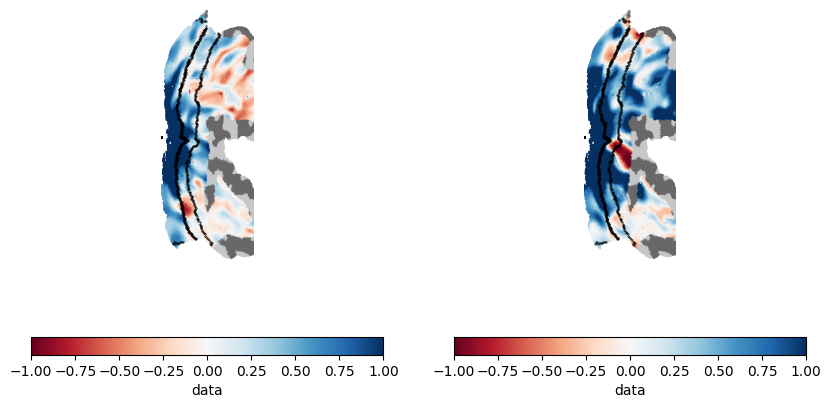

In [410]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
plot_kwargs = dict(
    # 
    flat_name='flatcut', 
    vmin=-1, vmax=1, 
    cmap='RdBu', hemi_list=['rh'], 
    roi_list=['b14_V1', 'b14_V2']

)
for i,k in enumerate([1,2]):
    gm.flat_mpl(
        data=z_fit[k],
        data_sub_mask=mask, 
        # data=surf_data[f'col_m_bw{k}'],
        ax=axs[i], 
        **plot_kwargs
    )
    axs[i].set_xlim(0,100)
    axs[i].set_aspect(1)

## old

In [71]:
# Get m
# meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
r2_th = results_glmsingle['typeb']['R2'] #>20
# brainmask = meanvol > 2500
beta_id = {
    'bw' : [0,3,4,7],
    'col':[1,2,5,6],
}
betas = {}
for k in beta_id.keys():
    betas[k] = []
    for i in beta_id[k]:
        betas[k].append(results_glmsingle['typec']['betasmd'][:,:,:,i])
    betas[k] = np.nanmean(betas[k], axis=0)

# bth = betas.copy()
# for k in bth.keys():
    
#     bth[k][~brainmask] = np.nan
#     bth[k][~r2_th] = np.nan


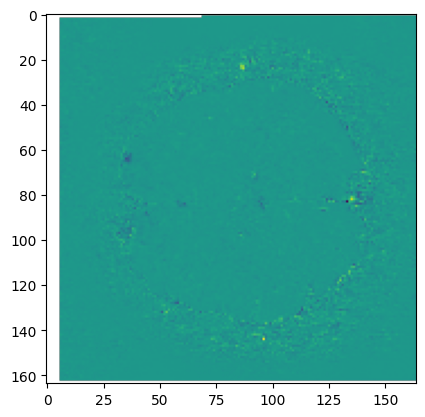

In [72]:
plt.imshow(betas['bw'][:,:,25]-betas['col'][:,:,25])

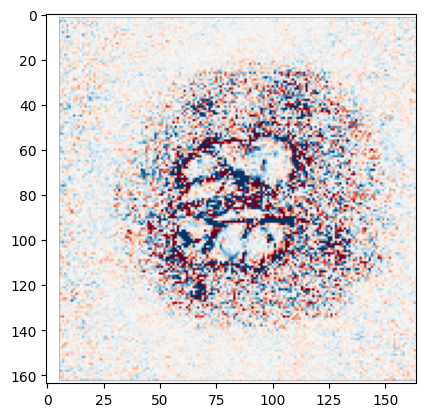

In [74]:
plt.imshow(
    # betas['bw'][:,:,-10],
    np.nanmean(results_glmsingle['typed']['betasmd'][:,:,-10,:], axis=-1),
    vmin=-5, vmax=5, cmap='RdBu',
    # vmin=0, vmax=1,
           )

16.183075


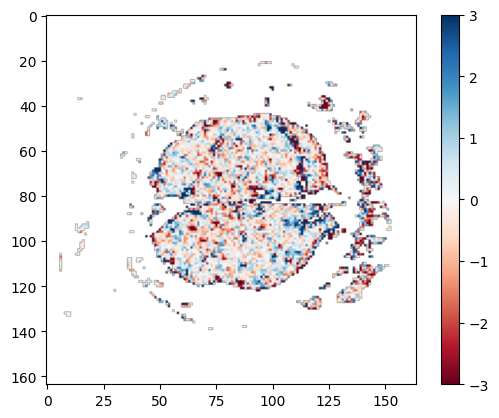

In [75]:
isl = -15
tdata = betas['bw'][:,:,isl] #np.nanmean(results_glmsingle['typec']['betasmd'][:,:,-10, :], axis=-1)
tdata =  betas['col'][:,:,isl] -  betas['bw'][:,:,isl] 
tmask = results_glmsingle['typed']['meanvol'][:,:,isl]>4000
tdata[~tmask] = np.nan
print(np.nanmax(tdata))
#results_glmsingle['typec']['meanvol'][:,:,-10]>3200,
plt.imshow(
    # betas['bw'][:,:,-10],
    tdata,
    vmin=-3, vmax=3, cmap='RdBu',
    # vmin=0, vmax=1,
           )
plt.colorbar()

In [76]:
tdata = betas['col'] -  betas['bw']
tmask = results_glmsingle['typec']['meanvol']>5000
tdata[~tmask] = np.nan
timg = nib.Nifti1Image(tdata.astype(np.float32), rnib[0].affine)
tfile = opj(outputdir_glmsingle, 'colmbw_mv5000.nii.gz')
tfile_al = opj(outputdir_glmsingle, 'colmbw_mv5000al.nii.gz')

nib.save(timg, tfile)
func2anat(tfile)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03_prefprepBU/glmsingle001/colmbw_mv5000.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 1.00640   0.01063  -0.00120   1.53171;
-0.00182   0.31494   0.96683  -1.54320;
 0.00171  -0.95013   0.30831  -74.33028;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
error: File exists
error: WARNING: 944975 NaNs found in volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_single/sub-03_prefprepBU/glmsingle001/colmbw_mv5000.nii.gz...
 



Resampling
Output registration matrix is identity

mri_vol2vol done


In [77]:
import cortex
vols = {}
vols['col_m_bw'] = nib.load(tfile_al).get_fdata().transpose(2,1,0)
vols['tsnr'] = nib.load(opj(stest_dir, f'runtsnral.nii.gz')).get_fdata().transpose(2,1,0)
vols['mepi'] = nib.load(opj(stest_dir, f'runmeanal.nii.gz')).get_fdata().transpose(2,1,0)

maps = {}
maps['col_m_bw'] = cortex.Volume(
    vols['col_m_bw'], sub, xfmname='identity',
    vmin=-3, vmax=3,
    cmap='RdBu_r'
)


for v in vols.keys():
    if v not in ('tsnr', 'mepi'):        
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            vmin=-3, vmax=3,
            cmap='RdBu_r'
        )
    else:
        maps[v] = cortex.Volume(
            vols[v], sub, xfmname='identity',
            vmin=-3, vmax=3,
            cmap='RdBu_r'
        )



maps['b14ecc']= cortex.Vertex(
    b14_info['ecc'], sub, 
    cmap='jet', vmin=0, vmax=10, 
)
maps['b14pol']= cortex.Vertex(
    b14_info['pol'], sub, 
    cmap='hsv', vmin=0, vmax=180, 
)



In [78]:

cortex.webshow(maps)

Started server on port 59699


<JS: window.viewer>